# 📊 Skills-Related Underemployment (SRU) by Sex

## Dataset Description
This dataset tracks the number and proportion of **working individuals with tertiary education who are employed in semi-skilled or low-skilled jobs** — a phenomenon known as **skills-related underemployment (SRU)**. Data is quarterly and broken down by **sex**.

This is one of the most direct measures for EduNilai's central question: *"Did the degree pay back?"*

## Data Source
| Field | Detail |
|---|---|
| **Publisher** | Department of Statistics Malaysia (DOSM) |
| **Survey** | Labour Force Survey (LFS), quarterly |
| **Catalogue page** | https://open.dosm.gov.my/data-catalogue/lfs_qtr_sru_sex |
| **Parquet URL** | `https://storage.dosm.gov.my/labour/lfs_qtr_sru_sex.parquet` |
| **License** | CC BY 4.0 |
| **Coverage** | 2016 Q1 – 2023 Q4 |

## Column Descriptions
| Column | Type | Description |
|---|---|---|
| `date` | date | Quarter and year (e.g. 2020-Q1) |
| `sex` | string | `overall`, `male`, or `female` |
| `sru` | integer | Number of tertiary-educated workers in semi/low-skill jobs (thousands) |
| `sru_prop` | float | Proportion of tertiary-educated workers that are underemployed (%) |

## Relevance to EduNilai
This dataset shows how many graduates are working in jobs that don’t require a degree. A high underemployment rate means lower earnings relative to the cost of education, making it a key indicator for assessing degree ROI.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

URL = 'https://storage.dosm.gov.my/labour/lfs_qtr_sru_sex.parquet'
df = pd.read_parquet(URL)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

df.head(10)

,date,variable,sex,sru
0,2017-01-01,rate,overall,29.9
1,2017-04-01,rate,overall,31.8
2,2017-07-01,rate,overall,31.4
3,2017-10-01,rate,overall,32.7
4,2018-01-01,rate,overall,32.5
5,2018-04-01,rate,overall,33.2
6,2018-07-01,rate,overall,33.4
7,2018-10-01,rate,overall,32.8
8,2019-01-01,rate,overall,32.9
9,2019-04-01,rate,overall,32.8


In [3]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nDate range:", df['date'].min(), "–", df['date'].max())
if 'sex' in df.columns:
    print("Sex categories:", df['sex'].unique())
print("\nDescriptive stats:")
print(df.describe())

Shape: (210, 4)
Columns: ['date', 'variable', 'sex', 'sru']

Date range: 2017-01-01 00:00:00 – 2025-07-01 00:00:00
Sex categories: ['overall' 'male' 'female']

Descriptive stats:
                                date          sru
count                            210   210.000000
mean   2021-04-01 04:06:51.428571392   586.274286
min              2017-01-01 00:00:00    27.800000
25%              2019-01-01 00:00:00    35.625000
50%              2021-04-01 00:00:00   304.750000
75%              2023-07-01 00:00:00   947.300000
max              2025-07-01 00:00:00  1961.500000
std                              NaN   634.536454


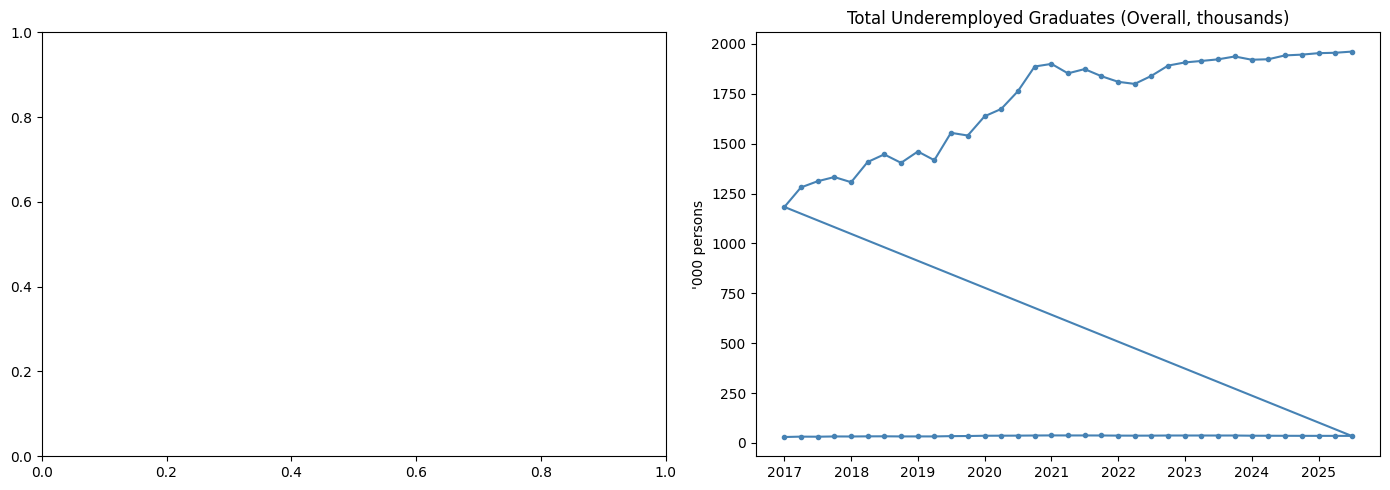

In [7]:
# SRU proportion trend by sex
df_overall = df[df['sex'] == 'overall'] if 'sex' in df.columns else df

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'sru_prop' in df.columns and 'sex' in df.columns:
    for sex, grp in df.groupby('sex'):
        axes[0].plot(grp['date'], grp['sru_prop'], label=sex, marker='o', markersize=3)
    axes[0].set_title('Graduate Underemployment Rate by Sex (%)')
    axes[0].set_ylabel('SRU Proportion (%)')
    axes[0].legend()

if 'sru' in df_overall.columns:
    axes[1].plot(df_overall['date'], df_overall['sru'], color='steelblue', marker='o', markersize=3)
    axes[1].set_title('Total Underemployed Graduates (Overall, thousands)')
    axes[1].set_ylabel("'000 persons")

plt.tight_layout()
plt.show()

In [ ]:
os.makedirs('../data/salary', exist_ok=True)
df.to_csv('../data/salary/graduate_underemployment_sex.csv', index=False, encoding='utf-8')
print("Saved -> ../data/salary/graduate_underemployment_sex.csv")
print(f"Rows exported: {len(df)}")